In [24]:
import os
import numpy as np
import matplotlib.pyplot as plt
import re
import cv2
from PIL import Image, ImageSequence
import av
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
import matplotlib.gridspec as gridspec


In [25]:
# Define the parameters used in grid search
kernel_sizes = list(range(5, 12, 2))  # 5, 7, 9, 11
rel_thresholds = [0.35, 0.45, 0.55, 0.65]  # 0.35, 0.45, 0.55, 0.65
compression_levels = [0, 1, 2, 3]  # 0, 1, 2, 3


In [26]:
# Reconstruction of the full array from the sparse data
def reconstruct_array(data):
    shape = tuple(data['shape'])
    fill_value = data['fill_value']
    coords = data['coords']
    sparse_data = data['data']

    full_array = np.full(shape, fill_value)
    for i, coord in enumerate(zip(*coords)):
        full_array[coord] = sparse_data[i]
    return full_array

# Load and plot the npz files
def load_and_plot_npz_files(folder_path, compression_level=0):
    # Double the number of columns to accommodate two images per condition
    fig, axs = plt.subplots(len(kernel_sizes), len(rel_thresholds) * 2, figsize=(15, 10))

    for root, dirs, files in os.walk(folder_path):
        for dir in dirs:
            kernel_size, rel_threshold, comp_level = extract_parameters(dir)

            if comp_level == compression_level:
                if kernel_size in kernel_sizes and rel_threshold in rel_thresholds:
                    file_paths = ['sequence-as-stack-MT0.N1.HD-BP-250.npz', 'sequence-as-stack-MT0.N1.HD-BP+250.npz'] # this is for the microtubule data
                    for index, file_name in enumerate(file_paths):
                        file_path = os.path.join(root, dir, file_name)
                        if os.path.exists(file_path):
                            data = np.load(file_path)
                            full_array = reconstruct_array(data)
                            selected_image = full_array[25]

                            # Find the correct subplot
                            i = kernel_sizes.index(kernel_size)
                            j = rel_thresholds.index(rel_threshold) * 2 + index

                            # Plot the selected image
                            axs[i, j].imshow(selected_image, cmap='gray', interpolation='none')
                            axs[i, j].axis('off')

                            # Set title for the first image of the pair
                            if index == 0:
                                axs[i, j].set_title(f'k{kernel_size} thr{rel_threshold}')

    plt.tight_layout()


      # Save the plot as a PDF
    plt.savefig('/Users/laurabreimann/Documents/Postdoc/Colabs/Compression/Figures/npz_profiles_240122.pdf', format='pdf')  

    plt.show()

# Extract the parameters from the folder name after the grid search
def extract_parameters(folder_name):
    match = re.search(r'k(\d+)_rt(\d+)_lev(\d+)', folder_name)
    if match:
        kernel_size = int(match.group(1))
        rel_threshold = float(f"0.{match.group(2)}")
        compression_level = int(match.group(3))
        return kernel_size, rel_threshold, compression_level
    else:
        return None, None, None

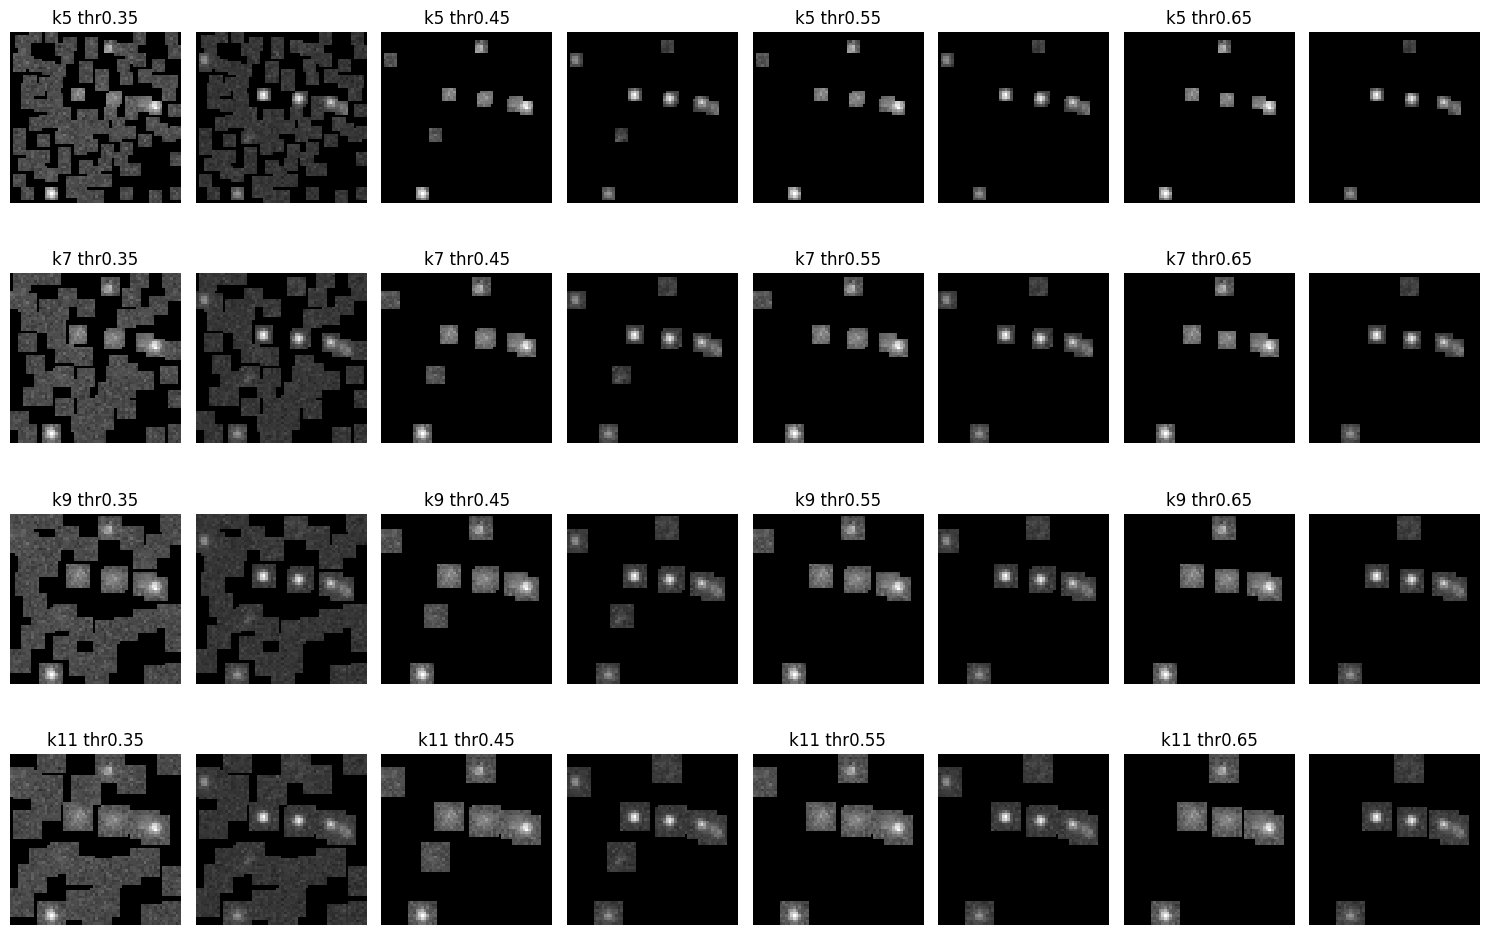

In [6]:

main_folder_path = "/Users/laurabreimann/Desktop/microtubule_data"
# Load and plot
load_and_plot_npz_files(main_folder_path)

In [4]:
def inspect_npz_file(file_path):
    with np.load(file_path) as data:
        print("Keys in the npz file:", data.files)
        # Display the shape of each array
        for key in data.files:
            print(f"Shape of the array under key '{key}':", data[key].shape)

# Test a npz file from the microtubule data
file_path = "/Users/laurabreimann/Desktop/microtubule_data/sparz_k5_rt35_lev0/sequence-as-stack-MT0.N1.HD-BP-250.npz"  
inspect_npz_file(file_path)

FileNotFoundError: [Errno 2] No such file or directory: '/Users/laurabreimann/Desktop/microtubule_data/sparz_k5_rt35_lev0/sequence-as-stack-MT0.N1.HD-BP-250.npz'

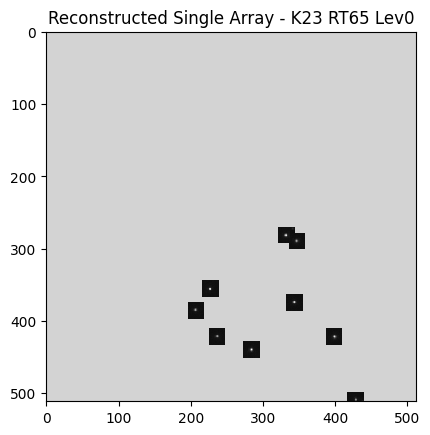

In [29]:
import matplotlib.colors as mcolors

def reconstruct_and_plot_single_npz(file_path):
    with np.load(file_path) as data:
        shape = tuple(data['shape'])
        fill_value = data['fill_value']
        coords = data['coords']
        sparse_data = data['data']

        full_array = np.full(shape, fill_value)
        for i, coord in enumerate(zip(*coords)):
            full_array[coord] = sparse_data[i]

        # Select one image to display
        selected_image = full_array[50]

        # Define a custom colormap with light gray for the background
        cmap = plt.cm.gray
        cmap.set_under('lightgray')  # Set color for values below the colormap range

        plt.imshow(selected_image, cmap=cmap, interpolation='none', norm=mcolors.Normalize(vmin=0.1, vmax=np.max(selected_image)))
        plt.title(f"Reconstructed Single Array - K23 RT65 Lev0") 
       # plt.colorbar()
        plt.show()

# Example usage
file_path = "/Users/laurabreimann/Desktop/DNA-PAINT_2/sparz_k23_rt65_lev0/RawFramesforTraining_P5-IS_20pM.npz" 
reconstruct_and_plot_single_npz(file_path)

In [10]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
import imageio.v2 as imageio
import numpy as np
import ffmpeg
from reader import imread as vimread
from dask import array as da

In [11]:


def read_frame_ffmpeg(file_path, frame_number):
    try:
        out, _ = (
            ffmpeg
            .input(file_path)
            .filter('select', f'gte(n,{frame_number})')  # Select the specific frame
            .output('pipe:', vframes=1, format='rawvideo', pix_fmt='gray12le')  # Output in grayscale format
            .run(capture_stdout=True, capture_stderr=True)
        )
        # We need to convert the buffer directly into a single-channel image.
        # Assuming the frame size is known (e.g., 64x64), adjust accordingly.
        frame_width, frame_height = 64, 64  # Replace with actual dimensions
        frame = (
            np.frombuffer(out, np.uint16)  # Read the buffer as 16-bit data
            .reshape([frame_height, frame_width])  # Reshape to the frame's dimensions
        )
        # Note: The 12-bit data is packed into 16-bit format, with the 4 least significant bits unused.
        return frame
    except ffmpeg.Error as e:
        print("ffmpeg error:", e.stderr.decode())
        return None

def normalize_image_16bit_to_8bit(img, min_val, max_val):
    # Ensure the image is in 16-bit format
    img_16bit = img.astype(np.uint16)
    
    # Normalize the image based on the min and max values
    img_norm = (img_16bit - min_val) / (max_val - min_val) * 65535
    img_norm = np.clip(img_norm, 0, 65535)  # Ensure the values are within 16-bit range

    # Scale down to 8-bit for display
    img_norm_8bit = (img_norm / 256).astype(np.uint8)
    return img_norm_8bit


def normalize_image(img, min_val, max_val):
    # Ensure the image is in 16-bit format
    #img_16bit = img.astype(np.uint16)
    
    # Normalize the image based on the min and max values
    img_norm = (img - min_val) / (max_val - min_val) * 65535
    #img_norm = np.clip(img_norm, 0, 65535)  # Ensure the values are within 16-bit range

    # Scale down to 8-bit for display
   # img_norm_8bit = (img_norm / 256).astype(np.uint8)
    return img_norm




def read_tiff_frame(image_path, frame_number):
    with Image.open(image_path) as img:
        # Seek to the specified frame
        img.seek(frame_number)
        frame = np.array(img)
        if frame.ndim == 2:  # If the image is grayscale
            return frame
        else:  # If the image is colored, convert to grayscale
            return cv2.cvtColor(frame, cv2.COLOR_RGB2GRAY)




In [12]:
# Frame number to extract
frame_number = 25  # Example frame number
tiff_frame_number = 25

# Paths to your video files
video_paths = [
   ["/Users/laurabreimann/Desktop/microtubule_data/sparz_k5_rt35_lev0/sequence-as-stack-MT0.N1.HD-BP+250_compression_level_0.mp4",
    "/Users/laurabreimann/Desktop/microtubule_data/sparz_k5_rt35_lev0/sequence-as-stack-MT0.N1.HD-BP-250_compression_level_0.mp4"],
    ["/Users/laurabreimann/Desktop/microtubule_data/sparz_k5_rt35_lev1/sequence-as-stack-MT0.N1.HD-BP+250_compression_level_1.mp4",
    "/Users/laurabreimann/Desktop/microtubule_data/sparz_k5_rt35_lev1/sequence-as-stack-MT0.N1.HD-BP-250_compression_level_1.mp4"],
    ["/Users/laurabreimann/Desktop/microtubule_data/sparz_k5_rt35_lev2/sequence-as-stack-MT0.N1.HD-BP+250_compression_level_2.mp4", 
    "/Users/laurabreimann/Desktop/microtubule_data/sparz_k5_rt35_lev2/sequence-as-stack-MT0.N1.HD-BP-250_compression_level_2.mp4"], 
     ["/Users/laurabreimann/Desktop/microtubule_data/sparz_k5_rt35_lev3/sequence-as-stack-MT0.N1.HD-BP+250_compression_level_3.mp4", 
     "/Users/laurabreimann/Desktop/microtubule_data/sparz_k5_rt35_lev3/sequence-as-stack-MT0.N1.HD-BP-250_compression_level_3.mp4"]
]


# Read the original TIFF images
original_image_path1 = "/Users/laurabreimann/Documents/Postdoc/Colabs/Compression/testing_sparz/simulated_tubulin/sequence-as-stack-MT0.N1.HD-BP+250_t.tif"
original_image1 = read_tiff_frame(original_image_path1, tiff_frame_number)

original_image_path2 = "/Users/laurabreimann/Documents/Postdoc/Colabs/Compression/testing_sparz/simulated_tubulin/sequence-as-stack-MT0.N1.HD-BP-250_t.tif"
original_image2 = read_tiff_frame(original_image_path2, tiff_frame_number)

# Find min and max pixel values from compression level 0 images
min_val = original_image2.min()
print(min_val)
max_val = original_image2.max()
print(max_val)

# Normalize original_image1 to the same range as original_image2
original_image1_normalized = normalize_image_16bit_to_8bit(original_image1, min_val, max_val)
#original_image2_normalized = normalize_image(original_image2, min_val, max_val)

431
2434


/var/folders/n4/82zt36bj3190s97jwk9jxc580000gn/T/ipykernel_72753/3710440602.py:64: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


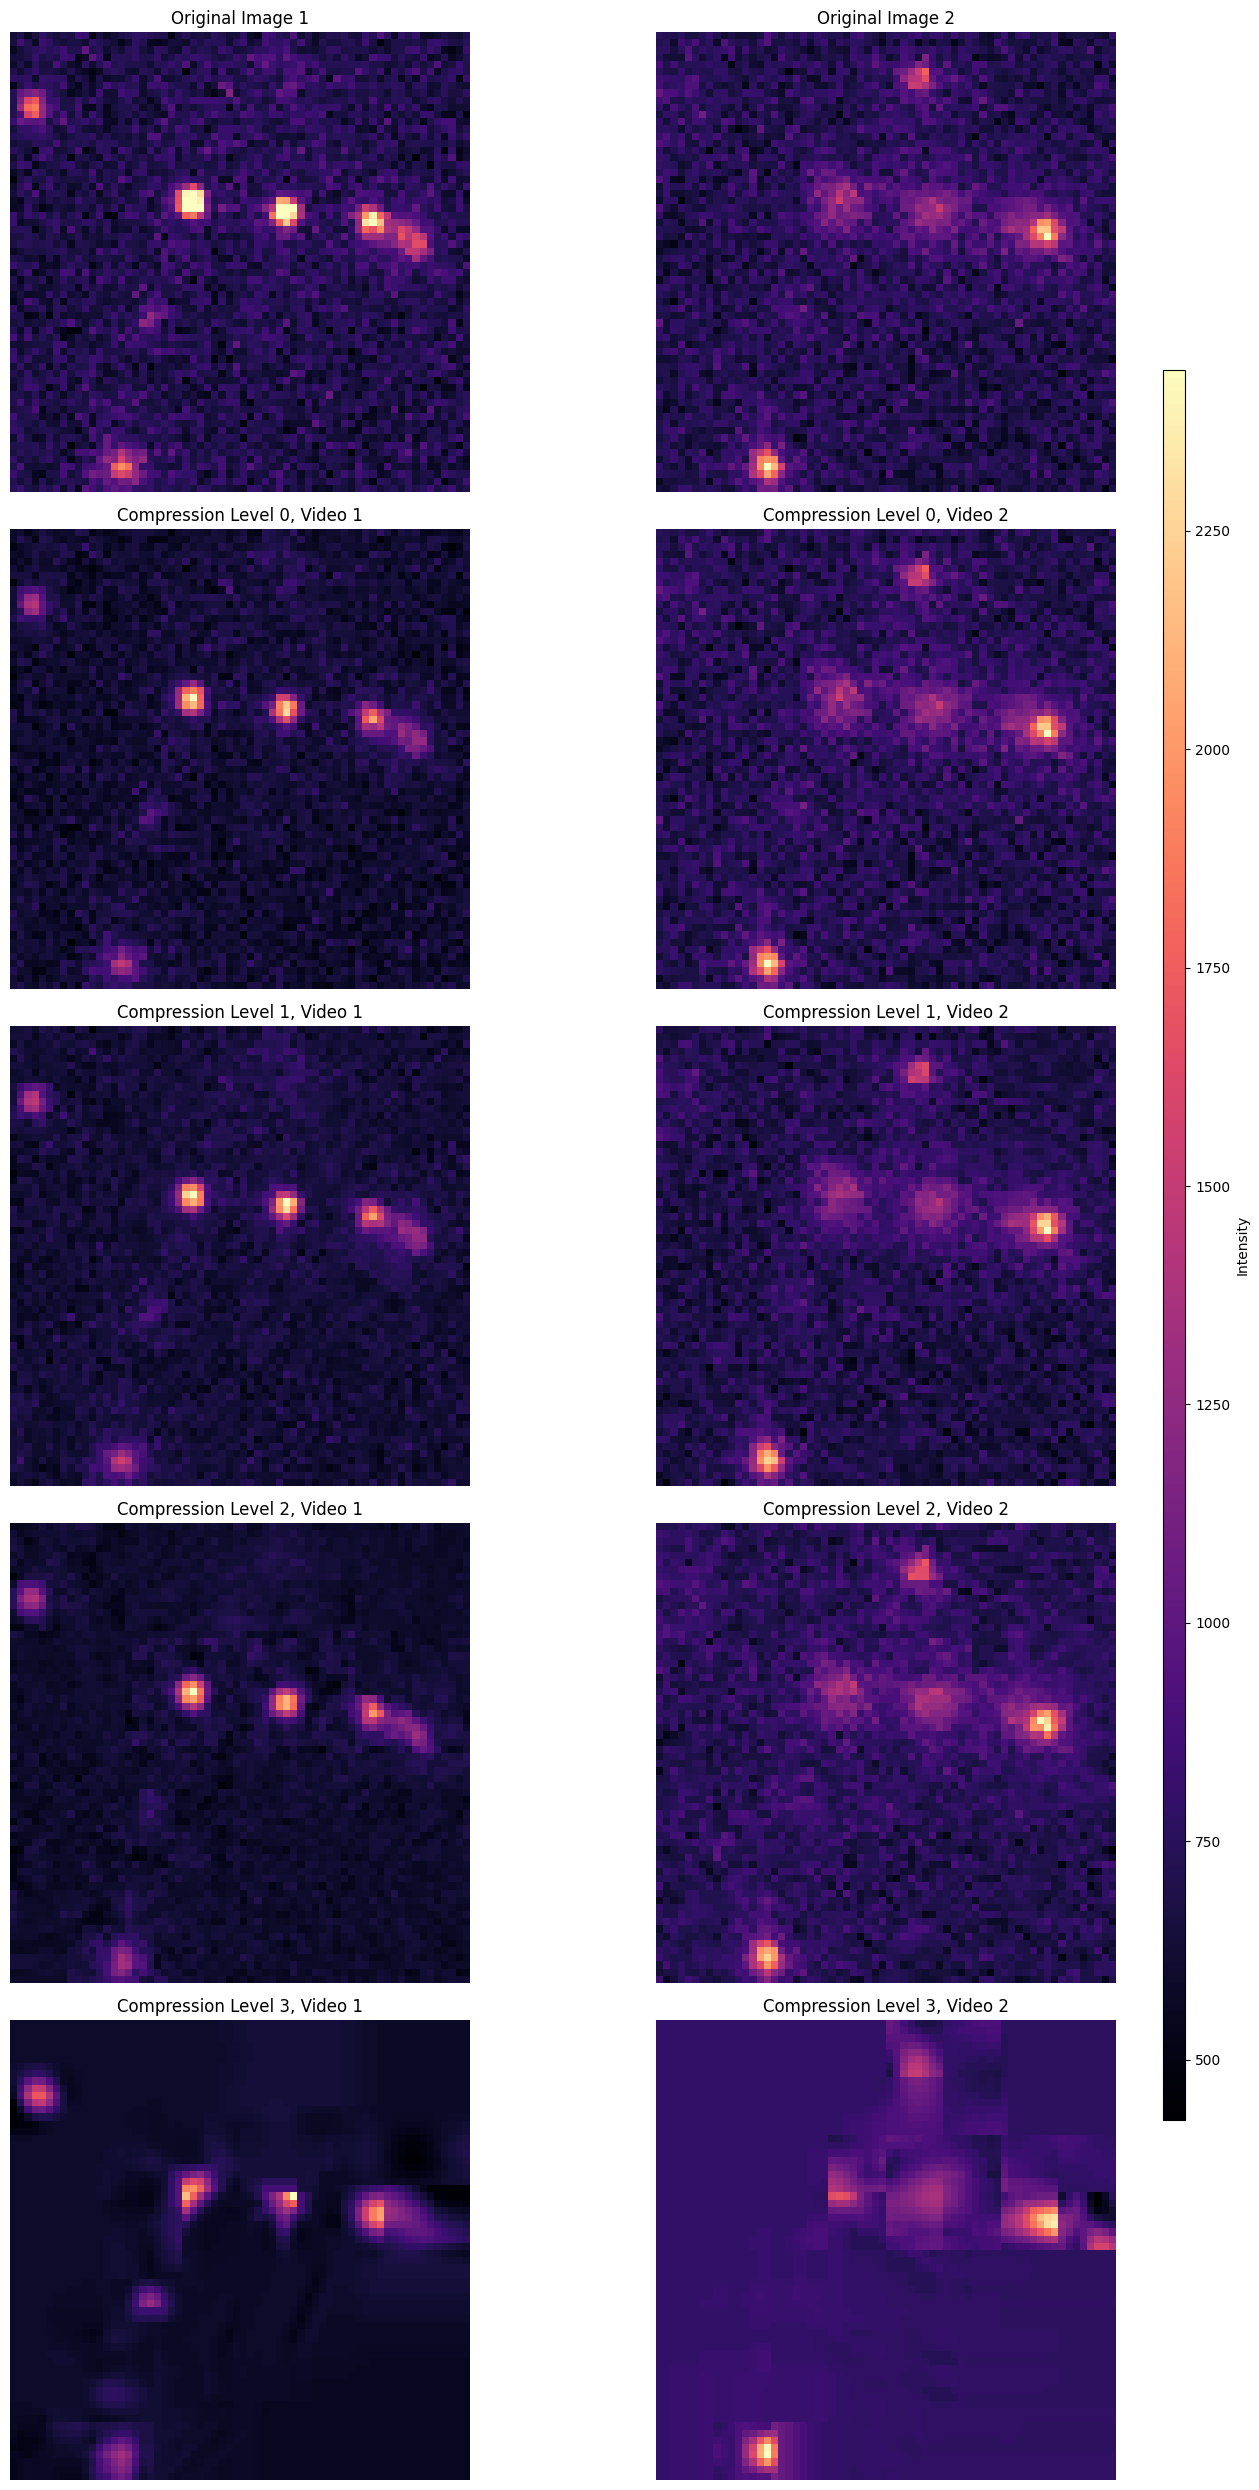

In [13]:
# Number of rows and columns for the plot
num_rows = len(video_paths) +1 
num_cols = 2  # Two videos per compression level

fig = plt.figure(figsize=(15, num_rows * 5))  # Adjust the figure size as needed

# Create a gridspec layout with 1 column for the color bar
gs = gridspec.GridSpec(num_rows, num_cols + 1, width_ratios=[1, 1, 0.05], wspace=0.3, hspace=0.3)


# Add the first original image as the first subplot
plt.subplot(num_rows, num_cols, 1)
plt.imshow(original_image1_normalized, cmap='magma',  interpolation='none')
plt.title("Original Image 1")
plt.axis('off')

# Add the second original image as the second subplot
plt.subplot(num_rows, num_cols, 2)
plt.imshow(original_image2, cmap='magma',  interpolation='none')
plt.title("Original Image 2")
plt.axis('off')


for i, level_paths in enumerate(video_paths):
    for j, path in enumerate(level_paths):
        # Use vimread to read the entire video as a dask array
        video_dask_array = vimread(path, dtypes='uint16')
        
        # Index the dask array to get the frame you want
        frame_dask = video_dask_array[frame_number]
        
        # Compute the dask array to get the NumPy array of the frame
        frame_data = frame_dask.compute()
        
        # Normalize the frame if it was successfully extracted
        # Ensure you're using a normalization function that's appropriate for 16-bit data
        frame_normalized = normalize_image_16bit_to_8bit(frame_data, np.min(frame_data), np.max(frame_data))
        
        # Add subplot for the compressed frame
        plt.subplot(num_rows, num_cols, (i + 1) * num_cols + j + 1)
        plt.imshow(frame_normalized, cmap='magma', interpolation='none')
        plt.title(f"Compression Level {i}, Video {j + 1}")
        plt.axis('off')



# Select the last column of the first row for the color bar
cbar_ax = fig.add_axes([0.9, 0.15, 0.015, 0.7])  # Adjust these values as necessary

# Create a color bar with the specified axes
norm = Normalize(vmin=min_val, vmax=max_val)
sm = ScalarMappable(cmap='magma', norm=norm)
sm.set_array([])

# Add the color bar to the figure
cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_label('Intensity')

# Adjust layout
fig.subplots_adjust(wspace=0.4, hspace=0.4)  # Adjust white space to your liking


# Adjust the layout and save
plt.tight_layout()
plt.savefig('/Users/laurabreimann/Documents/Postdoc/Colabs/Compression/Figures/mp4_profiles_240122.pdf', format='pdf', bbox_inches='tight')
plt.show()

In [14]:


def read_frame(file_path, frame_number):
    container = av.open(file_path)
    stream = container.streams.video[0]
    for frame in container.decode(stream):
        if frame.index == frame_number:
            # Convert the frame to 'rgb24' format which is widely supported
            frame_rgb = frame.to_ndarray(format='rgb24')
            # If the original content is grayscale, you can just take one channel
            frame_gray = frame_rgb[:, :, 0]
            # Now, frame_gray is an 8-bit grayscale image
            return frame_gray
    return None




def normalize_image_16bit_to_8bit(img, min_val, max_val):
    # Ensure the image is in 16-bit format
    img_16bit = img.astype(np.uint16)
    
    # Normalize the image based on the min and max values
    img_norm = (img_16bit - min_val) / (max_val - min_val) * 65535
    img_norm = np.clip(img_norm, 0, 65535)  # Ensure the values are within 16-bit range

    # Scale down to 8-bit for display
    img_norm_8bit = (img_norm / 256).astype(np.uint8)
    return img_norm_8bit


def normalize_image(img, min_val, max_val):
    # Ensure the image is in 16-bit format
    #img_16bit = img.astype(np.uint16)
    
    # Normalize the image based on the min and max values
    img_norm = (img - min_val) / (max_val - min_val) * 65535
    #img_norm = np.clip(img_norm, 0, 65535)  # Ensure the values are within 16-bit range

    # Scale down to 8-bit for display
   # img_norm_8bit = (img_norm / 256).astype(np.uint8)
    return img_norm




def read_tiff_frame(image_path, frame_number):
    with Image.open(image_path) as img:
        # Seek to the specified frame
        img.seek(frame_number)
        frame = np.array(img)
        if frame.ndim == 2:  # If the image is grayscale
            return frame
        else:  # If the image is colored, convert to grayscale
            return cv2.cvtColor(frame, cv2.COLOR_RGB2GRAY)




In [15]:
# Frame number to extract
frame_number = 25  # Example frame number
tiff_frame_number = 25

# Paths to your video files
video_paths = [
   ["/Users/laurabreimann/Desktop/microtubule_data/sparz_k9_rt45_lev0/uncompressed/MT0_sequence-as-stack-MT0.N1.HD-BP+250_compression_level_0.tiff",
    "/Users/laurabreimann/Desktop/microtubule_data/sparz_k9_rt45_lev0/uncompressed/MT0_sequence-as-stack-MT0.N1.HD-BP-250_compression_level_0.tiff"],
   ["/Users/laurabreimann/Desktop/microtubule_data/sparz_k9_rt45_lev1/uncompressed/MT0_sequence-as-stack-MT0.N1.HD-BP+250_compression_level_1.tiff",
    "/Users/laurabreimann/Desktop/microtubule_data/sparz_k9_rt45_lev1/uncompressed/MT0_sequence-as-stack-MT0.N1.HD-BP-250_compression_level_1.tiff"],
   ["/Users/laurabreimann/Desktop/microtubule_data/sparz_k9_rt45_lev2/uncompressed/MT0_sequence-as-stack-MT0.N1.HD-BP+250_compression_level_2.tiff", 
    "/Users/laurabreimann/Desktop/microtubule_data/sparz_k9_rt45_lev2/uncompressed/MT0_sequence-as-stack-MT0.N1.HD-BP-250_compression_level_2.tiff"], 
   ["/Users/laurabreimann/Desktop/microtubule_data/sparz_k9_rt45_lev3/uncompressed/MT0_sequence-as-stack-MT0.N1.HD-BP+250_compression_level_3.tiff", 
    "/Users/laurabreimann/Desktop/microtubule_data/sparz_k9_rt45_lev3/uncompressed/MT0_sequence-as-stack-MT0.N1.HD-BP-250_compression_level_3.tiff"]
]


# Read the original TIFF images
original_image_path1 = "/Users/laurabreimann/Documents/Postdoc/Colabs/Compression/testing_sparz/simulated_tubulin/sequence-as-stack-MT0.N1.HD-BP+250_t.tif"
original_image1 = read_tiff_frame(original_image_path1, tiff_frame_number)

original_image_path2 = "/Users/laurabreimann/Documents/Postdoc/Colabs/Compression/testing_sparz/simulated_tubulin/sequence-as-stack-MT0.N1.HD-BP-250_t.tif"
original_image2 = read_tiff_frame(original_image_path2, tiff_frame_number)

# Find min and max pixel values from compression level 0 images
min_val = original_image2.min()
print(min_val)
max_val = original_image2.max()
print(max_val)

# Normalize original_image1 to the same range as original_image2
original_image1_normalized = normalize_image_16bit_to_8bit(original_image1, min_val, max_val)
#original_image2_normalized = normalize_image(original_image2, min_val, max_va

431
2434


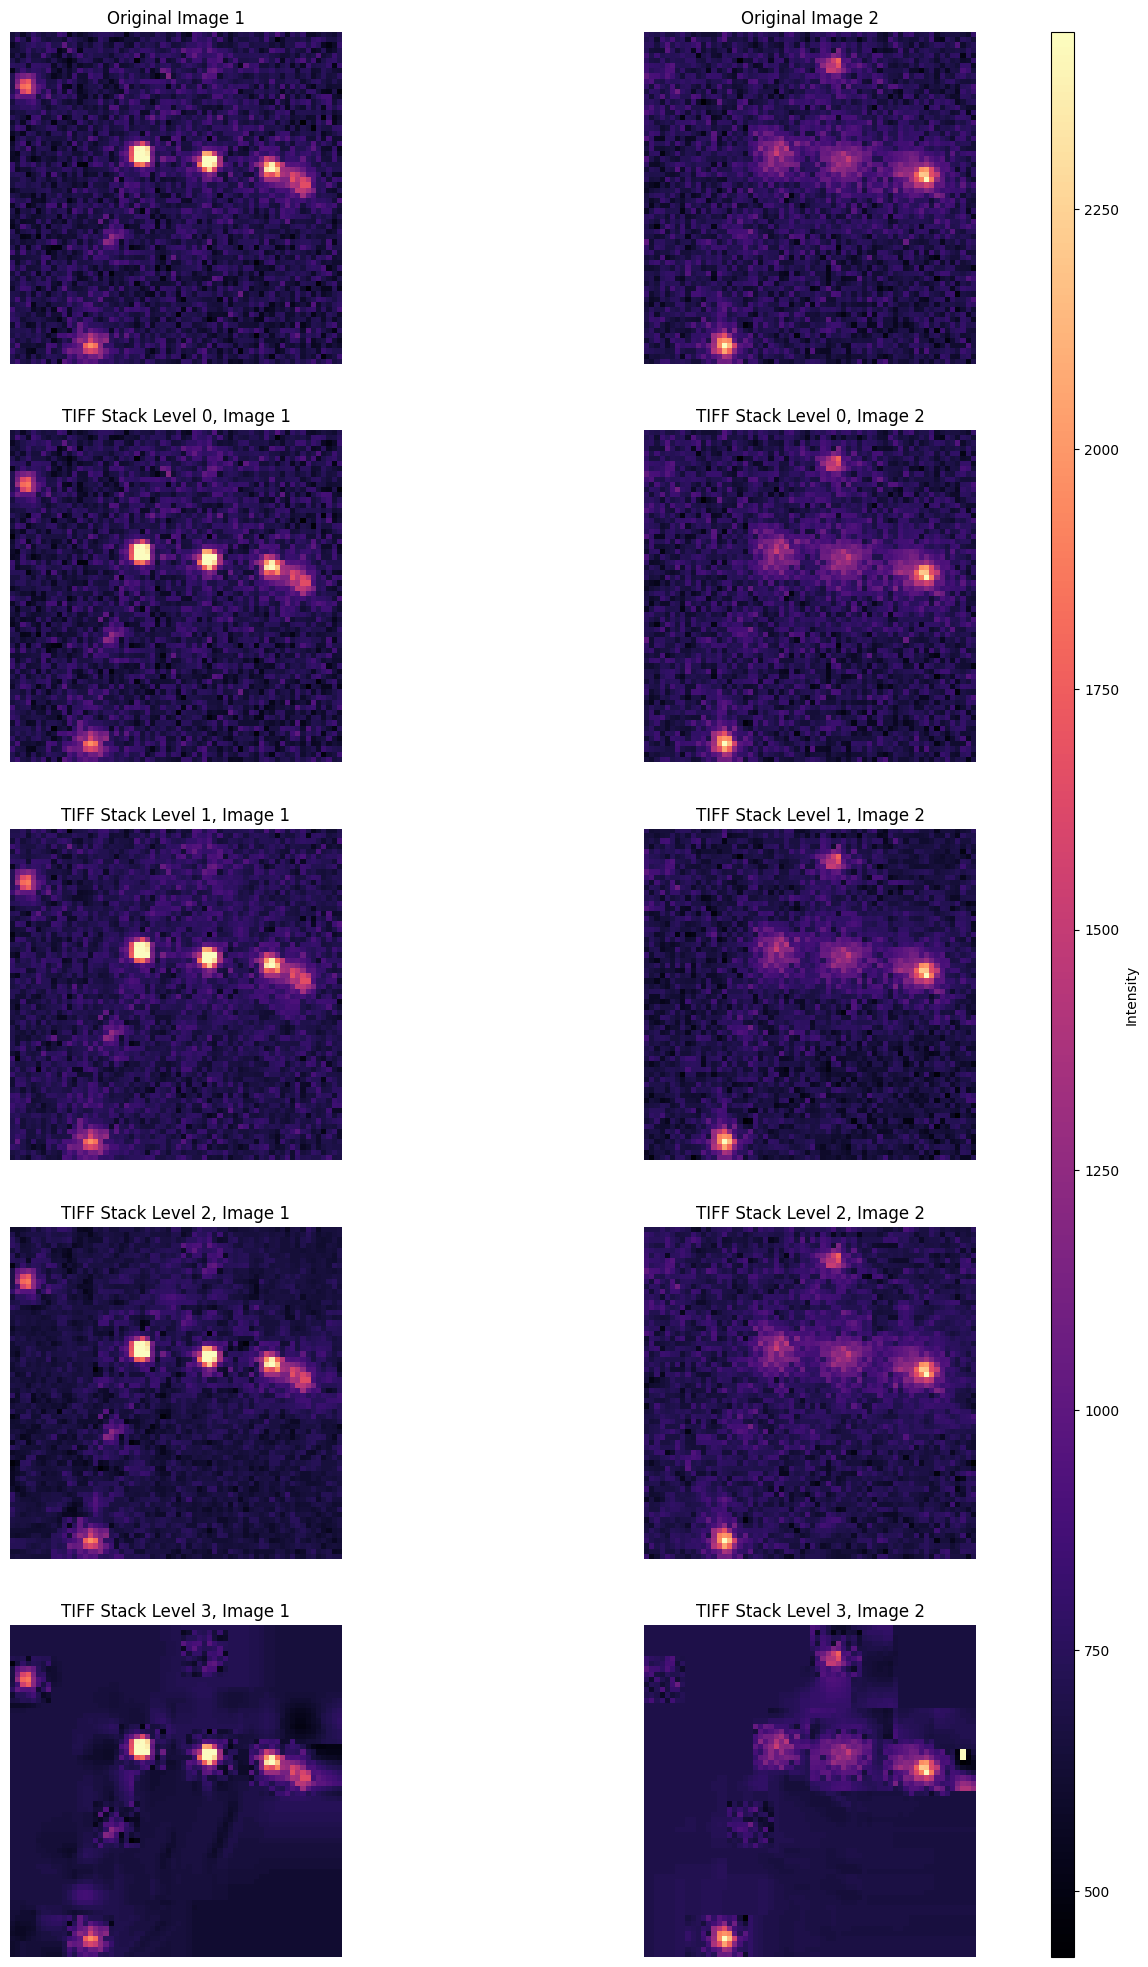

In [16]:
# Number of rows and columns for the plot
num_rows = len(video_paths) +1 
num_cols = 2  # Two videos per compression level

fig = plt.figure(figsize=(15, num_rows * 5))  # Adjust the figure size as needed

# Create a gridspec layout with 1 column for the color bar
gs = gridspec.GridSpec(num_rows, num_cols + 1, width_ratios=[1, 1, 0.05], wspace=0.3, hspace=0.3)


# Add the first original image as the first subplot
plt.subplot(num_rows, num_cols, 1)
plt.imshow(original_image1_normalized, cmap='magma',  interpolation='none')
plt.title("Original Image 1")
plt.axis('off')

# Add the second original image as the second subplot
plt.subplot(num_rows, num_cols, 2)
plt.imshow(original_image2, cmap='magma',  interpolation='none')
plt.title("Original Image 2")
plt.axis('off')


for i, level_paths in enumerate(video_paths):
    for j, path in enumerate(level_paths):
        # Extract frame from TIFF stack
        frame = read_tiff_frame(path, frame_number)
        if frame is not None:
            # Normalize the frame if it was successfully extracted
            frame_normalized = normalize_image_16bit_to_8bit(frame, min_val, max_val)

            # Add subplot for the frame from the TIFF stack
            plt.subplot(num_rows, num_cols, (i + 1) * num_cols + j + 1)
            plt.imshow(frame_normalized, cmap='magma',  interpolation='none')
            plt.title(f"TIFF Stack Level {i}, Image {j + 1}")
            plt.axis('off')




# Now add the color bar in the last column of the grid
cbar_ax = fig.add_subplot(gs[:, -1])
norm = Normalize(vmin=min_val, vmax=max_val)
sm = ScalarMappable(cmap='magma', norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, cax=cbar_ax)
cbar.set_label('Intensity')

# Save and show the figure
plt.savefig('/Users/laurabreimann/Documents/Postdoc/Colabs/Compression/Figures/sparunzip_profiles_240122.pdf', format='pdf')
plt.show()

In [149]:
from reader import imread as vimread
from dask import array as da

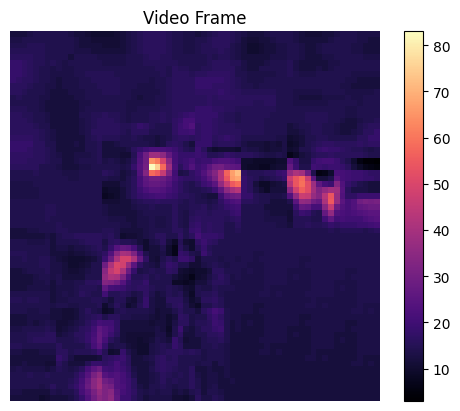

In [153]:
# Assuming vimread is already defined as shown in your provided class
# and is capable of reading MP4 files while preserving the 16-bit depth.

# Example usage of vimread to read a single frame from an MP4 video
video_dask_array = vimread('/Users/laurabreimann/Desktop/microtubule_data_2/sparz_k5_rt35_lev3/sequence-as-stack-MT0.N1.HD-BP+250_compression_level_3.mp4')


frame_number=25
# Index the dask array to get the frame you want.
# frame_number should be zero-based indexing.
frame_dask = video_dask_array[frame_number]

frame_data = frame_dask.compute()


# Normalize and plot the frame as required.
# Ensure you're using a normalization function that's appropriate for 16-bit data.
frame_normalized = normalize_image_16bit_to_8bit(frame_data, np.min(frame), np.max(frame))

# Plotting the normalized frame
plt.imshow(frame_normalized, cmap='magma')
plt.colorbar()  # Add a colorbar to visualize the intensity range
plt.title('Video Frame')
plt.axis('off')
plt.show()